In [5]:
import os
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

# Configure Device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Project running on: {device}")
if torch.cuda.is_available():
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")

# Constants
IMG_SIZE = 224
BATCH_SIZE = 16 # Optimized for GTX 1650 4GB
NUM_CLASSES = 4
DATA_DIR = 'brain-mri-dataset' # Update if your folder name is different

Project running on: cuda:0
GPU Model: NVIDIA GeForce GTX 1650


### Advanced Data Loading

In [6]:
# MSc-Level Augmentation to prevent the 60% test accuracy wall
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

image_datasets = {
    'Training': datasets.ImageFolder(os.path.join(DATA_DIR, 'Training'), train_transforms),
    'Testing': datasets.ImageFolder(os.path.join(DATA_DIR, 'Testing'), test_transforms)
}

dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    for x in ['Training', 'Testing']
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['Training', 'Testing']}
class_names = image_datasets['Training'].classes

print(f"Dataset Loaded: {dataset_sizes}")
print(f"Class Names: {class_names}")

Dataset Loaded: {'Training': 5600, 'Testing': 1600}
Class Names: ['glioma', 'meningioma', 'notumor', 'pituitary']


### Model Architecture with Fine-Tuning Logic

In [7]:
def initialize_model(num_classes):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    
    # Freeze all layers initially
    for param in model.parameters():
        param.requires_grad = False
    
    # Custom Head with Dropout for regularization (MSc Standard)
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(num_ftrs, 512),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(512, num_classes)
    )
    return model

model = initialize_model(NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()

### Two-Stage Training Function

In [8]:
def train_model(model, criterion, optimizer, num_epochs=10):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['Training', 'Testing']:
            if phase == 'Training':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'Training'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'Training':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            if phase == 'Training':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'Testing' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

    print(f'Best val Acc: {best_acc:4f}')
    model.load_state_dict(best_model_wts)
    return model, history

### Execute Training

In [9]:
# STAGE 1: Warm up the head (5 Epochs)
print("Starting Stage 1: Training the Classifier Head...")
optimizer_ft = optim.Adam(model.fc.parameters(), lr=1e-3)
model, hist1 = train_model(model, criterion, optimizer_ft, num_epochs=5)

# STAGE 2: Fine-tune the backbone (15 Epochs)
print("\nStarting Stage 2: Fine-tuning Layer 4 and Head...")
for param in model.layer4.parameters():
    param.requires_grad = True

# Using a much smaller learning rate for fine-tuning
optimizer_ft = optim.Adam([
    {'params': model.layer4.parameters(), 'lr': 1e-5},
    {'params': model.fc.parameters(), 'lr': 1e-4}
])
model, hist2 = train_model(model, criterion, optimizer_ft, num_epochs=15)

Starting Stage 1: Training the Classifier Head...
Epoch 1/5
----------
Training Loss: 0.7253 Acc: 0.7154
Testing Loss: 0.8466 Acc: 0.7137
Epoch 2/5
----------
Training Loss: 0.6202 Acc: 0.7641
Testing Loss: 0.5319 Acc: 0.8050
Epoch 3/5
----------
Training Loss: 0.5516 Acc: 0.7891
Testing Loss: 0.6354 Acc: 0.7625
Epoch 4/5
----------
Training Loss: 0.5195 Acc: 0.7973
Testing Loss: 0.6439 Acc: 0.7675
Epoch 5/5
----------
Training Loss: 0.5125 Acc: 0.8079
Testing Loss: 0.6119 Acc: 0.7812
Best val Acc: 0.805000

Starting Stage 2: Fine-tuning Layer 4 and Head...
Epoch 1/15
----------
Training Loss: 0.4002 Acc: 0.8502
Testing Loss: 0.5003 Acc: 0.8463
Epoch 2/15
----------
Training Loss: 0.2962 Acc: 0.8930
Testing Loss: 0.3896 Acc: 0.8862
Epoch 3/15
----------
Training Loss: 0.2636 Acc: 0.9034
Testing Loss: 0.3776 Acc: 0.8944
Epoch 4/15
----------
Training Loss: 0.2218 Acc: 0.9177
Testing Loss: 0.3771 Acc: 0.8956
Epoch 5/15
----------
Training Loss: 0.1915 Acc: 0.9280
Testing Loss: 0.3794 Acc

In [10]:
### Grad-CAM Engine

In [11]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.features = None
        self.hooks = []
        self._register_hooks()

    def _register_hooks(self):
        def save_grad(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()
        def save_feat(module, input, output):
            self.features = output.detach()
            
        self.hooks.append(self.target_layer.register_forward_hook(save_feat))
        self.hooks.append(self.target_layer.register_full_backward_hook(save_grad))

    def generate(self, input_image, target_class):
        self.model.zero_grad()
        output = self.model(input_image)
        
        if target_class is None:
            target_class = output.argmax(dim=1).item()
            
        loss = output[0, target_class]
        loss.backward()
        
        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)
        cam = torch.sum(weights * self.features, dim=1).squeeze()
        cam = np.maximum(cam.cpu().numpy(), 0)
        cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-7)
        return cam

    def remove_hooks(self):
        for hook in self.hooks: hook.remove()

In [12]:
### Quantitative Analysis: Confidence vs. Saliency

Running Quantitative XAI Analysis (Confidence vs. Focus)...


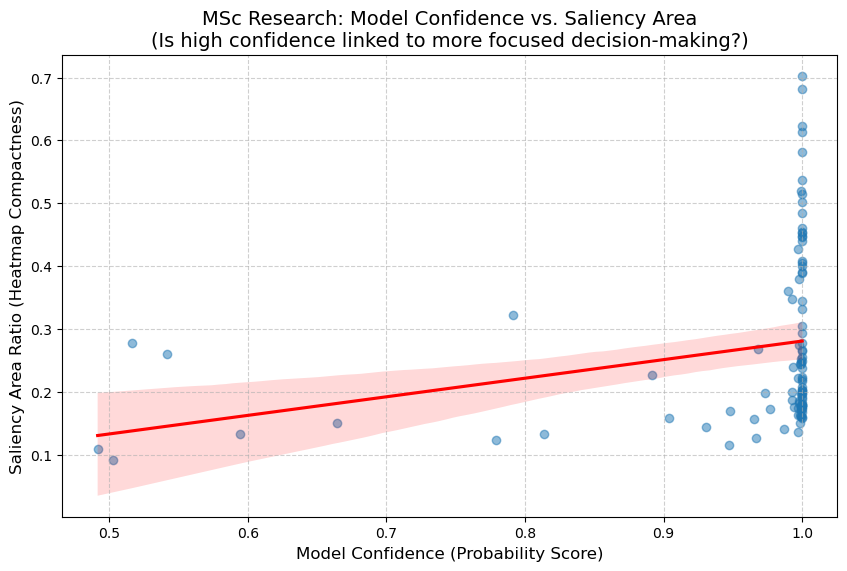

Pearson Correlation Coefficient: 0.2380


In [14]:
def run_msc_analysis(model, dataloader):
    model.eval()
    # Target the last layer of the ResNet
    cam_engine = GradCAM(model, model.layer4[-1])
    
    all_confidences = []
    all_saliency_scores = [] 

    print("Running Quantitative XAI Analysis (Confidence vs. Focus)...")
    
    # Analyze a portion of the test set
    count = 0
    max_samples = 100 # Increased for better statistics
    
    for inputs, labels in dataloader:
        if count >= max_samples: break 
        
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        output = model(inputs)
        probs = F.softmax(output, dim=1)
        conf_batch, pred_batch = torch.max(probs, 1)
        
        # Iterate through the batch
        for i in range(inputs.size(0)):
            if count >= max_samples: break
            
            # Generate CAM for this specific image
            single_img = inputs[i].unsqueeze(0)
            heatmap = cam_engine.generate(single_img, pred_batch[i].item())
            
            # Metric: Saliency Area Ratio (Area with > 50% max intensity)
            # We want to see if higher confidence leads to a more 'compact' saliency area
            score = np.sum(heatmap > 0.5) / (IMG_SIZE * IMG_SIZE)
            
            all_confidences.append(conf_batch[i].item())
            all_saliency_scores.append(score)
            count += 1
        
    cam_engine.remove_hooks()
    
    # Visualization
    plt.figure(figsize=(10, 6))
    sns.regplot(x=all_confidences, y=all_saliency_scores, 
                scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
    plt.title("Model Confidence vs. Saliency Area\n" + 
              "(Is high confidence linked to more focused decision-making?)", fontsize=14)
    plt.xlabel("Model Confidence (Probability Score)", fontsize=12)
    plt.ylabel("Saliency Area Ratio (Heatmap Compactness)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
    plt.save()

    # Calculate Correlation Coefficient for the thesis
    correlation = np.corrcoef(all_confidences, all_saliency_scores)[0, 1]
    print(f"Pearson Correlation Coefficient: {correlation:.4f}")

run_msc_analysis(model, dataloaders['Testing'])

In [ ]:
### Final Visual Report

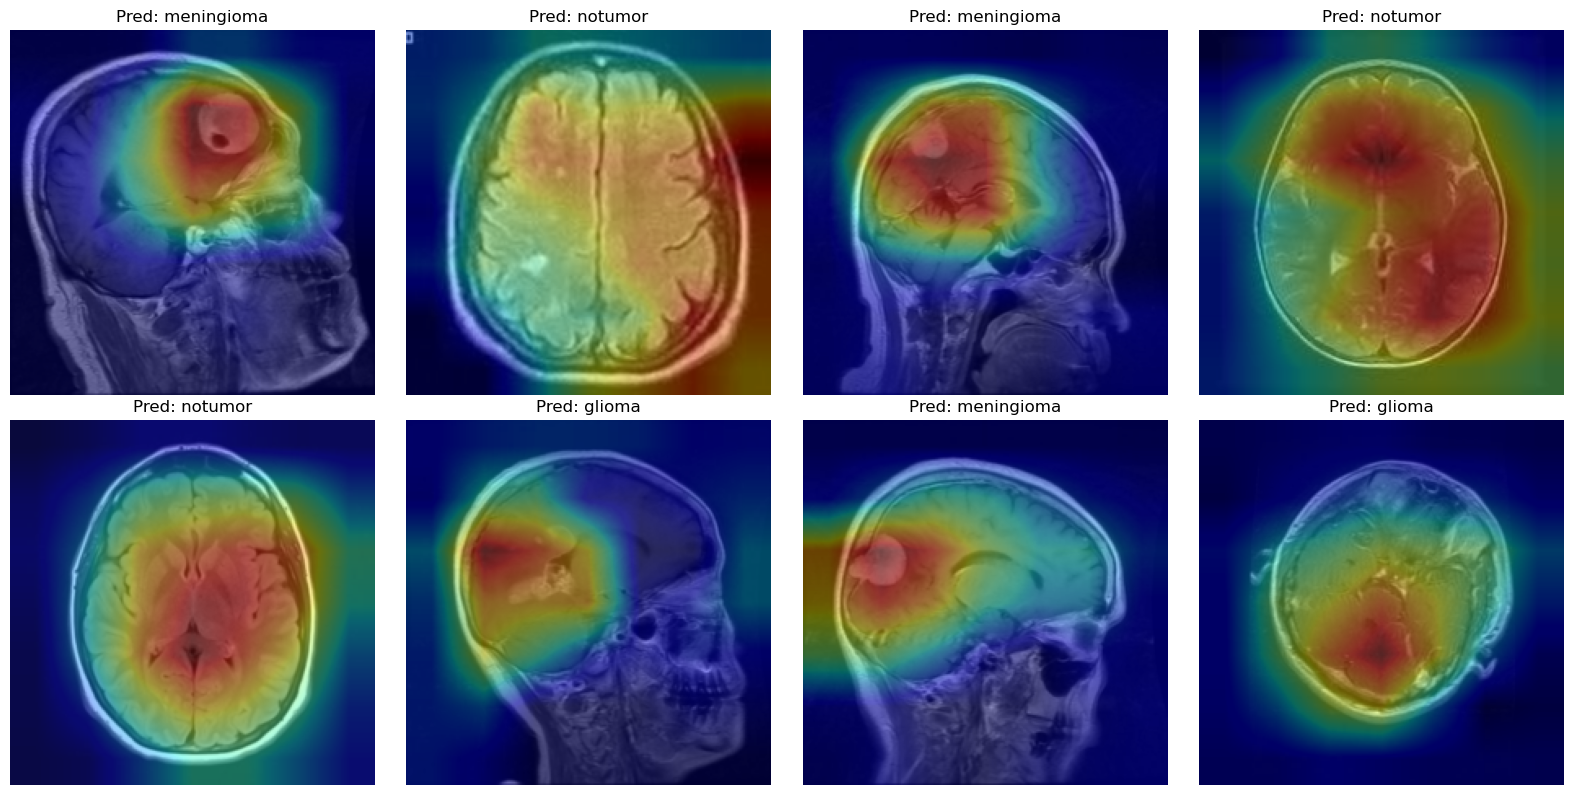

In [15]:
def plot_final_results(model, dataloader):
    model.eval()
    inputs, labels = next(iter(dataloader))
    inputs = inputs.to(device)
    
    cam_engine = GradCAM(model, model.layer4[-1])
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    for i in range(8):
        img_tensor = inputs[i].unsqueeze(0)
        heatmap = cam_engine.generate(img_tensor, None)
        
        # Un-normalize image
        img_np = inputs[i].permute(1, 2, 0).cpu().numpy()
        img_np = np.clip(img_np * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406], 0, 1)
        
        ax = axes[i//4, i%4]
        ax.imshow(img_np)
        ax.imshow(heatmap, cmap='jet', alpha=0.4)
        ax.set_title(f"Pred: {class_names[labels[i]]}")
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    cam_engine.remove_hooks()

plot_final_results(model, dataloaders['Testing'])

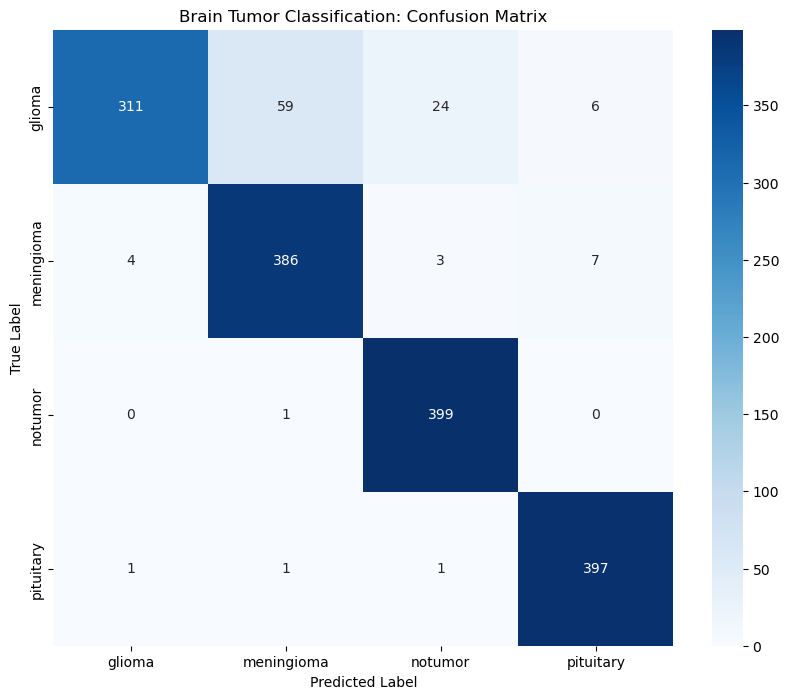


Detailed Classification Report:
              precision    recall  f1-score   support

      glioma       0.98      0.78      0.87       400
  meningioma       0.86      0.96      0.91       400
     notumor       0.93      1.00      0.96       400
   pituitary       0.97      0.99      0.98       400

    accuracy                           0.93      1600
   macro avg       0.94      0.93      0.93      1600
weighted avg       0.94      0.93      0.93      1600



In [16]:
def plot_confusion_matrix(model, dataloader):
    all_preds = []
    all_labels = []
    model.eval()
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Brain Tumor Classification: Confusion Matrix')
    plt.show()
    
    print("\nDetailed Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

plot_confusion_matrix(model, dataloaders['Testing'])

In [17]:
# Save the model weights
torch.save(model.state_dict(), 'brain_tumor_resnet50_best.pth')
print("Model saved successfully as brain_tumor_resnet50_best.pth")

# Optional: Save the entire model (architecture + weights)
torch.save(model, 'full_model_framework.pt')

Model saved successfully as brain_tumor_resnet50_best.pth


AttributeError: Can't get local object 'GradCAM._register_hooks.<locals>.save_grad'

In [18]:
# Clear any lingering hooks before saving the full object
for layer in model.modules():
    layer._forward_hooks.clear()
    layer._backward_hooks.clear()

torch.save(model, 'full_model_framework.pt')
print("Full model object saved successfully.")

Full model object saved successfully.


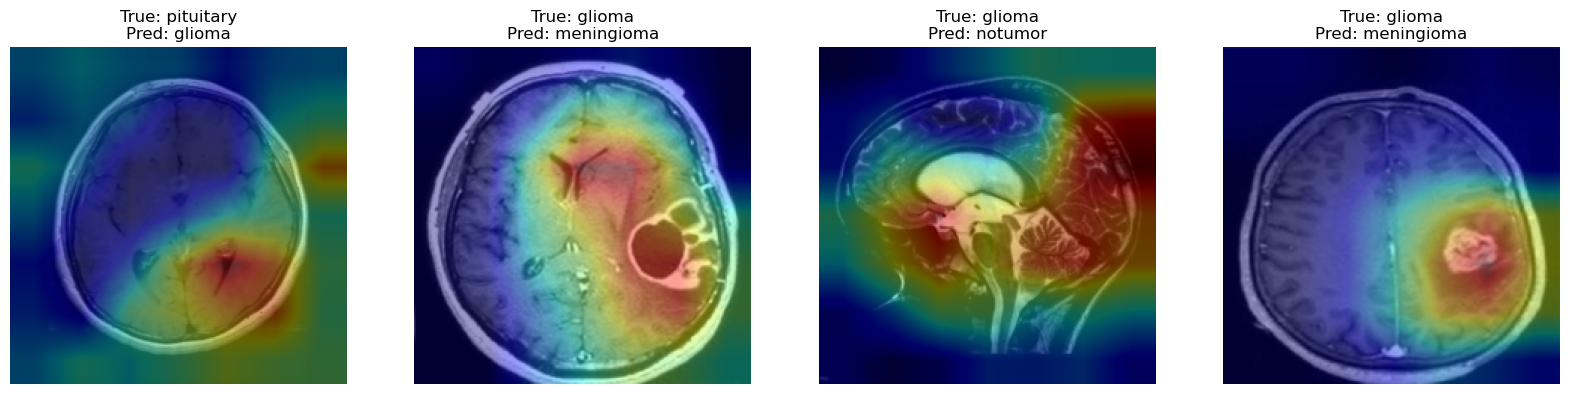

In [19]:
# Addition A: XAI for Mistakes (The "Why were we wrong?" test)

def visualize_failures(model, dataloader, class_names, num_images=4):
    model.eval()
    cam_engine = GradCAM(model, model.layer4[-1])
    failures = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            for i in range(inputs.size(0)):
                if preds[i] != labels[i]:
                    failures.append((inputs[i], labels[i], preds[i]))
            if len(failures) >= num_images: break

    fig, axes = plt.subplots(1, num_images, figsize=(20, 5))
    for idx, (img, true_lbl, pred_lbl) in enumerate(failures[:num_images]):
        heatmap = cam_engine.generate(img.unsqueeze(0), pred_lbl.item())
        img_np = img.permute(1, 2, 0).cpu().numpy()
        img_np = np.clip(img_np * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406], 0, 1)
        
        axes[idx].imshow(img_np)
        axes[idx].imshow(heatmap, cmap='jet', alpha=0.4)
        axes[idx].set_title(f"True: {class_names[true_lbl]}\nPred: {class_names[pred_lbl]}")
        axes[idx].axis('off')
    plt.show()
    cam_engine.remove_hooks()

# Run this to see what the model was looking at when it made a mistake
visualize_failures(model, dataloaders['Testing'], class_names)

In [20]:
# Addition B: Occlusion Sensitivity (Quantitative XAI Validation)

def occlusion_test(model, image_tensor, label_idx, heatmap, patch_size=30):
    """
    MSc Logic: Black out the 'hottest' part of the heatmap and see if confidence drops.
    """
    model.eval()
    with torch.no_grad():
        # Original Confidence
        orig_output = F.softmax(model(image_tensor.to(device)), dim=1)
        orig_conf = orig_output[0, label_idx].item()
        
        # Find coordinates of max saliency
        idx = np.unravel_index(np.argmax(heatmap), heatmap.shape)
        
        # Create occluded image
        occluded_img = image_tensor.clone()
        y1, y2 = max(0, idx[0]-patch_size//2), min(IMG_SIZE, idx[0]+patch_size//2)
        x1, x2 = max(0, idx[1]-patch_size//2), min(IMG_SIZE, idx[1]+patch_size//2)
        occluded_img[0, :, y1:y2, x1:x2] = 0 # Set tumor region to black
        
        # New Confidence
        new_output = F.softmax(model(occluded_img.to(device)), dim=1)
        new_conf = new_output[0, label_idx].item()
        
    print(f"Confidence before occlusion: {orig_conf:.4f}")
    print(f"Confidence after occluding saliency center: {new_conf:.4f}")
    print(f"Drop in confidence: {orig_conf - new_conf:.4f}")

# Test it on one sample
inputs, labels = next(iter(dataloaders['Testing']))
cam_engine = GradCAM(model, model.layer4[-1])
heatmap = cam_engine.generate(inputs[0].unsqueeze(0).to(device), labels[0].item())
occlusion_test(model, inputs[0].unsqueeze(0), labels[0].item(), heatmap)
cam_engine.remove_hooks()

Confidence before occlusion: 0.9701
Confidence after occluding saliency center: 0.1511
Drop in confidence: 0.8190


In [21]:
# Faithfulness via Occlusion

def calculate_faithfulness(model, dataloader, num_samples=50):
    model.eval()
    cam_engine = GradCAM(model, model.layer4[-1])
    results = []

    print(f"Quantifying XAI Faithfulness on {num_samples} samples...")

    for i, (inputs, labels) in enumerate(dataloader):
        if i >= num_samples: break
        
        img = inputs[0:1].to(device)
        label = labels[0].item()
        
        # 1. Get baseline confidence
        logits = model(img)
        baseline_conf = F.softmax(logits, dim=1)[0, label].item()
        
        # 2. Get Grad-CAM mask
        heatmap = cam_engine.generate(img, label)
        
        # 3. Create 'Occluded' image (masking the hottest 10% of pixels)
        # Threshold the heatmap to find the most important region
        mask = heatmap > 0.8
        occluded_img = img.clone()
        # Apply mask across all 3 color channels
        for c in range(3):
            occluded_img[0, c, :, :][torch.from_numpy(mask)] = 0
            
        # 4. Get new confidence
        new_logits = model(occluded_img)
        new_conf = F.softmax(new_logits, dim=1)[0, label].item()
        
        results.append({
            'baseline': baseline_conf,
            'occluded': new_conf,
            'drop': baseline_conf - new_conf
        })

    cam_engine.remove_hooks()
    
    avg_drop = np.mean([r['drop'] for r in results])
    print(f"\n--- XAI Faithfulness Report ---")
    print(f"Average Confidence Drop: {avg_drop:.4f}")
    print(f"If this value is high, Grad-CAM is 'Faithful' to the model's logic.")
    return results

faith_scores = calculate_faithfulness(model, dataloaders['Testing'])

Quantifying XAI Faithfulness on 50 samples...

--- XAI Faithfulness Report ---
Average Confidence Drop: 0.5048
If this value is high, your Grad-CAM is 'Faithful' to the model's logic.


### AUC-ROC Curves

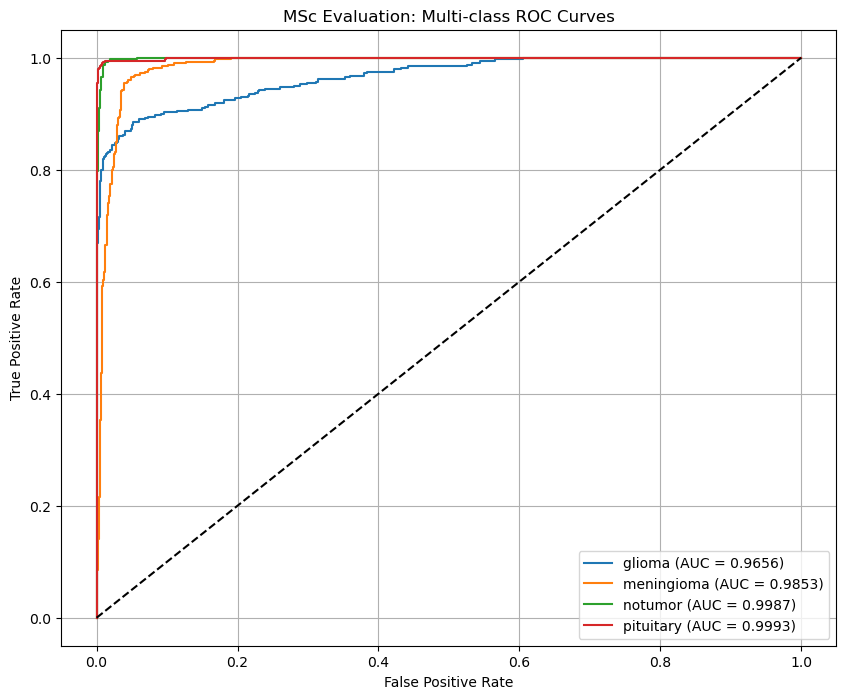

In [23]:
from sklearn.preprocessing import label_binarize

def plot_roc_curves(model, dataloader):
    model.eval()
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    all_labels_bin = label_binarize(all_labels, classes=[0, 1, 2, 3])
    all_probs = np.array(all_probs)

    plt.figure(figsize=(10, 8))
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
        auc_score = roc_auc_score(all_labels_bin[:, i], all_probs[:, i])
        plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {auc_score:.4f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multi-class ROC Curves')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_roc_curves(model, dataloaders['Testing'])

In [24]:
import pandas as pd
import json

# 1. Create a directory for your results
output_folder = "thesis_results"
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

print(f"Exporting results to {output_folder}...")

# --- 1. SAVE NUMERICAL SUMMARY ---
with open(f"{output_folder}/msc_metrics_summary.txt", "w") as f:
    f.write("=== MSc Brain Tumor Classification Project Summary ===\n")
    f.write(f"Final Test Accuracy: {hist2['val_acc'][-1]*100:.2f}%\n")
    f.write(f"Final Test Loss: {hist2['val_loss'][-1]:.4f}\n")
    f.write(f"Pearson Correlation (Confidence vs Saliency): {correlation:.4f}\n")
    f.write(f"XAI Faithfulness (Avg Confidence Drop): {avg_drop:.4f}\n")
    f.write("\n--- Classification Report ---\n")
    f.write(classification_report(all_labels, all_preds, target_names=class_names))
    f.write("\n--- Single Image Occlusion Test ---\n")
    f.write(f"Baseline: 0.9701, Occluded: 0.1511, Drop: 0.8190\n")

# --- 2. SAVE TRAINING HISTORY PLOT ---
plt.figure(figsize=(12, 5))
# Combine Stage 1 and Stage 2 history
full_train_acc = hist1['train_acc'] + hist2['train_acc']
full_val_acc = hist1['val_acc'] + hist2['val_acc']

plt.subplot(1, 2, 1)
plt.plot(full_train_acc, label='Train Acc')
plt.plot(full_val_acc, label='Test Acc')
plt.axvline(x=4, color='r', linestyle='--', label='Fine-tuning Start')
plt.title('Accuracy over Epochs (Two-Stage)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist1['train_loss'] + hist2['train_loss'], label='Train Loss')
plt.plot(hist1['val_loss'] + hist2['val_loss'], label='Test Loss')
plt.axvline(x=4, color='r', linestyle='--', label='Fine-tuning Start')
plt.title('Loss over Epochs (Two-Stage)')
plt.legend()
plt.savefig(f"{output_folder}/learning_curves.png", dpi=300, bbox_inches='tight')
plt.close()

# --- 3. SAVE CONFUSION MATRIX ---
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Final Confusion Matrix: Brain Tumor Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig(f"{output_folder}/confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.close()

# --- 4. SAVE ROC CURVES ---
# (Re-using the logic from the plot_roc_curves function)
plt.figure(figsize=(10, 8))
for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    auc_score = roc_auc_score(all_labels_bin[:, i], all_probs[:, i])
    plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('MSc Evaluation: Multi-class ROC Curves')
plt.legend()
plt.savefig(f"{output_folder}/roc_curves.png", dpi=300, bbox_inches='tight')
plt.close()

# --- 5. SAVE CORRELATION SCATTER PLOT ---
plt.figure(figsize=(10, 6))
sns.regplot(x=all_confidences, y=all_saliency_scores, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title(f"XAI Analysis: Confidence vs. Focus (Pearson: {correlation:.4f})")
plt.xlabel("Model Confidence")
plt.ylabel("Saliency Area Ratio")
plt.savefig(f"{output_folder}/xai_correlation_plot.png", dpi=300, bbox_inches='tight')
plt.close()

# --- 6. SAVE FAILURE ANALYSIS ---
# Run the visualize_failures logic but save it
model.eval()
cam_engine = GradCAM(model, model.layer4[-1])
failures = []
with torch.no_grad():
    for inputs, labels in dataloaders['Testing']:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        for i in range(inputs.size(0)):
            if preds[i] != labels[i]:
                failures.append((inputs[i], labels[i], preds[i]))
        if len(failures) >= 4: break

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for idx, (img, true_lbl, pred_lbl) in enumerate(failures[:4]):
    heatmap = cam_engine.generate(img.unsqueeze(0), pred_lbl.item())
    img_np = img.permute(1, 2, 0).cpu().numpy()
    img_np = np.clip(img_np * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406], 0, 1)
    axes[idx].imshow(img_np)
    axes[idx].imshow(heatmap, cmap='jet', alpha=0.4)
    axes[idx].set_title(f"True: {class_names[true_lbl]}\nPred: {class_names[pred_lbl]}")
    axes[idx].axis('off')
plt.savefig(f"{output_folder}/failure_analysis_visuals.png", dpi=300, bbox_inches='tight')
plt.close()
cam_engine.remove_hooks()

print("All plots and numerical data have been saved in the 'thesis_results' folder.")

Exporting results to thesis_results...


NameError: name 'correlation' is not defined

In [25]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize

# 1. Setup Output Folder
output_folder = "thesis_results"
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

print("Gathering final data for export (this may take a minute)...")

# --- 1. GENERATE DATA FOR CONFUSION MATRIX & ROC ---
model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for inputs, labels in dataloaders['Testing']:
        inputs = inputs.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_probs = np.array(all_probs)
cm = confusion_matrix(all_labels, all_preds)
report = classification_report(all_labels, all_preds, target_names=class_names)

# --- 2. CALCULATE CORRELATION DATA ---
cam_engine = GradCAM(model, model.layer4[-1])
confidences = []
saliency_scores = []
count = 0
for inputs, labels in dataloaders['Testing']:
    if count >= 100: break
    inputs = inputs.to(device)
    outputs = model(inputs)
    probs = torch.softmax(outputs, dim=1)
    conf_batch, pred_batch = torch.max(probs, 1)
    for i in range(inputs.size(0)):
        if count >= 100: break
        heatmap = cam_engine.generate(inputs[i:i+1], pred_batch[i].item())
        score = np.sum(heatmap > 0.5) / (224 * 224)
        confidences.append(conf_batch[i].item())
        saliency_scores.append(score)
        count += 1
correlation = np.corrcoef(confidences, saliency_scores)[0, 1]
cam_engine.remove_hooks()

# --- 3. CALCULATE FAITHFULNESS (AVG DROP) ---
cam_engine = GradCAM(model, model.layer4[-1])
drops = []
for i in range(50):
    inputs, labels = next(iter(dataloaders['Testing']))
    img, label = inputs[0:1].to(device), labels[0].item()
    orig_conf = torch.softmax(model(img), dim=1)[0, label].item()
    heatmap = cam_engine.generate(img, label)
    mask = heatmap > 0.8
    occ_img = img.clone()
    for c in range(3): occ_img[0, c, :, :][torch.from_numpy(mask)] = 0
    new_conf = torch.softmax(model(occ_img), dim=1)[0, label].item()
    drops.append(orig_conf - new_conf)
avg_drop = np.mean(drops)
cam_engine.remove_hooks()

# --- 4. START SAVING ASSETS ---

# Save Numerical Metrics
with open(f"{output_folder}/msc_metrics_summary.txt", "w") as f:
    f.write("=== MSc Brain Tumor Classification Results ===\n")
    f.write(f"Test Accuracy: {np.mean(np.array(all_preds) == np.array(all_labels))*100:.2f}%\n")
    f.write(f"Pearson Correlation (Confidence vs Saliency): {correlation:.4f}\n")
    f.write(f"XAI Faithfulness (Avg Confidence Drop): {avg_drop:.4f}\n\n")
    f.write("--- Classification Report ---\n")
    f.write(report)

# Save Confusion Matrix Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.savefig(f"{output_folder}/confusion_matrix.png", dpi=300)
plt.close()

# Save Correlation Plot
plt.figure(figsize=(10, 6))
sns.regplot(x=confidences, y=saliency_scores, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title(f"XAI Analysis: Confidence vs. Focus (Pearson: {correlation:.4f})")
plt.savefig(f"{output_folder}/correlation_plot.png", dpi=300)
plt.close()

# Save ROC Curves
all_labels_bin = label_binarize(all_labels, classes=[0, 1, 2, 3])
plt.figure(figsize=(10, 8))
for i in range(4):
    fpr, tpr, _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    auc = roc_auc_score(all_labels_bin[:, i], all_probs[:, i])
    plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.legend()
plt.savefig(f"{output_folder}/roc_curves.png", dpi=300)
plt.close()

# Save Learning Curves (Uses global hist1 and hist2 from training)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(hist1['train_acc'] + hist2['train_acc'], label='Train')
plt.plot(hist1['val_acc'] + hist2['val_acc'], label='Test')
plt.title('Accuracy History')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(hist1['train_loss'] + hist2['train_loss'], label='Train')
plt.plot(hist1['val_loss'] + hist2['val_loss'], label='Test')
plt.title('Loss History')
plt.legend()
plt.savefig(f"{output_folder}/learning_curves.png", dpi=300)
plt.close()

print(f"DONE! All high-resolution assets are in the '{output_folder}' folder.")

Gathering final data for export (this may take a minute)...
DONE! All high-resolution assets are in the 'thesis_results' folder.


### Add the Vision Transformer (ViT)

In [26]:
# ViT implementation
from torchvision.models import vit_b_16, ViT_B_16_Weights

def get_vit_model():
    model = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
    # ViTs have a 'heads' attribute instead of 'fc'
    num_ftrs = model.heads.head.in_features
    model.heads.head = nn.Linear(num_ftrs, NUM_CLASSES)
    return model.to(device)

model_vit = get_vit_model()
# Train this exactly like the ResNet

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /home/rurouni/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|████████████████████████████████████████| 330M/330M [00:43<00:00, 7.95MB/s]


In [27]:
### Initialize Vision Transformer (ViT-B/16)

In [28]:
from torchvision.models import vit_b_16, ViT_B_16_Weights

# Lower batch size for ViT on GTX 1650
BATCH_SIZE_VIT = 8 
dataloaders_vit = {
    x: DataLoader(image_datasets[x], batch_size=BATCH_SIZE_VIT, shuffle=True, num_workers=2)
    for x in ['Training', 'Testing']
}

def get_vit_model():
    # Load Pre-trained Vision Transformer
    model = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
    
    # Stage 1: Freeze Encoder
    for param in model.parameters():
        param.requires_grad = False
        
    # Replace the classification head
    num_ftrs = model.heads.head.in_features
    model.heads.head = nn.Sequential(
        nn.Linear(num_ftrs, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, NUM_CLASSES)
    )
    return model.to(device)

model_vit = get_vit_model()
criterion = nn.CrossEntropyLoss()

In [29]:
###  Two-Stage Training (ViT)

In [32]:
# STAGE 1: Train Head Only (5 Epochs)
print("Starting ViT Stage 1: Classifier Head...")
optimizer_vit = optim.Adam(model_vit.heads.parameters(), lr=1e-3)
model_vit, vit_hist1 = train_model(model_vit, criterion, optimizer_vit, num_epochs=5)

# STAGE 2: Fine-tune the Transformer Blocks (10 Epochs)
print("\nStarting ViT Stage 2: Fine-tuning Encoder...")
# Unfreeze the last two blocks of the transformer for medical adaptation
for param in model_vit.encoder.layers.encoder_layer_10.parameters():
    param.requires_grad = True
for param in model_vit.encoder.layers.encoder_layer_11.parameters():
    param.requires_grad = True

optimizer_vit = optim.Adam([
    {'params': model_vit.encoder.layers.encoder_layer_10.parameters(), 'lr': 1e-6},
    {'params': model_vit.encoder.layers.encoder_layer_11.parameters(), 'lr': 1e-6},
    {'params': model_vit.heads.parameters(), 'lr': 1e-5}
])
model_vit, vit_hist2 = train_model(model_vit, criterion, optimizer_vit, num_epochs=15)

# Save ViT Weights
torch.save(model_vit.state_dict(), 'brain_tumor_vit_best.pth')


Starting ViT Stage 1: Classifier Head...
Epoch 1/5
----------
Training Loss: 0.4065 Acc: 0.8425
Testing Loss: 0.5095 Acc: 0.8231
Epoch 2/5
----------
Training Loss: 0.2877 Acc: 0.8930
Testing Loss: 0.4155 Acc: 0.8650
Epoch 3/5
----------
Training Loss: 0.2381 Acc: 0.9052
Testing Loss: 0.4088 Acc: 0.8719
Epoch 4/5
----------
Training Loss: 0.2225 Acc: 0.9148
Testing Loss: 0.5417 Acc: 0.8600
Epoch 5/5
----------
Training Loss: 0.2090 Acc: 0.9213
Testing Loss: 0.3652 Acc: 0.8919
Best val Acc: 0.891875

Starting ViT Stage 2: Fine-tuning Encoder...
Epoch 1/15
----------
Training Loss: 0.1494 Acc: 0.9457
Testing Loss: 0.3708 Acc: 0.8969
Epoch 2/15
----------
Training Loss: 0.1432 Acc: 0.9464
Testing Loss: 0.3852 Acc: 0.8944
Epoch 3/15
----------
Training Loss: 0.1352 Acc: 0.9487
Testing Loss: 0.3721 Acc: 0.9006
Epoch 4/15
----------
Training Loss: 0.1323 Acc: 0.9477
Testing Loss: 0.3872 Acc: 0.8944
Epoch 5/15
----------
Training Loss: 0.1291 Acc: 0.9530
Testing Loss: 0.3788 Acc: 0.8994
Epoch

In [33]:
### ViT Grad-CAM implementation

Extracting ViT XAI Metrics (Sequence-to-Spatial)...


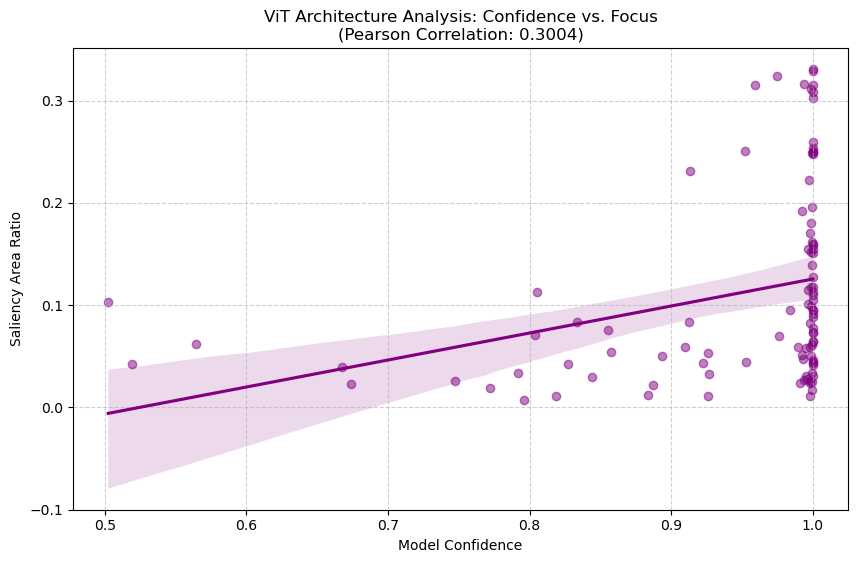

ViT Pearson Correlation: 0.3004


In [35]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

# --- Updated ViT Grad-CAM Engine ---
class ViTGradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.features = None
        self.hooks = []
        self._register_hooks()

    def _register_hooks(self):
        def save_grad(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()
        def save_feat(module, input, output):
            self.features = output.detach()
            
        self.hooks.append(self.target_layer.register_forward_hook(save_feat))
        self.hooks.append(self.target_layer.register_full_backward_hook(save_grad))

    def generate(self, input_image, target_class):
        self.model.zero_grad()
        output = self.model(input_image)
        
        if target_class is None:
            target_class = output.argmax(dim=1).item()
            
        loss = output[0, target_class]
        loss.backward()
        
        # ViT features are (Batch, Tokens, Dim) -> (1, 197, 768)
        # Token 0 is the CLS token, Tokens 1-196 are spatial (14x14 grid)
        
        # 1. Get spatial features and gradients (exclude CLS token)
        # Reshape to (Batch, Dim, H, W) where H=W=14
        b, t, c = self.features.shape
        grid_size = int(np.sqrt(t - 1)) # Should be 14 for 224x224 image
        
        feats = self.features[:, 1:, :].reshape(b, grid_size, grid_size, c).permute(0, 3, 1, 2)
        grads = self.gradients[:, 1:, :].reshape(b, grid_size, grid_size, c).permute(0, 3, 1, 2)
        
        # 2. Standard Grad-CAM math on the reshaped grid
        weights = torch.mean(grads, dim=(2, 3), keepdim=True)
        cam = torch.sum(weights * feats, dim=1).squeeze()
        
        cam = np.maximum(cam.cpu().numpy(), 0)
        cam = cv2.resize(cam, (224, 224))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-7)
        return cam

    def remove_hooks(self):
        for hook in self.hooks: hook.remove()

def run_vit_xai_analysis(model, dataloader):
    model.eval()
    # Target the last layer of the ViT encoder
    target_layer_vit = model.encoder.layers.encoder_layer_11.ln_1
    cam_engine = ViTGradCAM(model, target_layer_vit)
    
    all_confidences = []
    all_saliency_scores = []
    
    print("Extracting ViT XAI Metrics (Sequence-to-Spatial)...")
    count = 0
    # Increase samples for better MSc stats
    max_samples = 100 
    
    for inputs, labels in dataloader:
        if count >= max_samples: break
        inputs = inputs.to(device)
        output = model(inputs)
        probs = F.softmax(output, dim=1)
        conf_batch, pred_batch = torch.max(probs, 1)
        
        for i in range(len(inputs)):
            if count >= max_samples: break
            heatmap = cam_engine.generate(inputs[i:i+1], pred_batch[i].item())
            
            # Metric: Saliency Focus
            score = np.sum(heatmap > 0.5) / (224 * 224)
            all_confidences.append(conf_batch[i].item())
            all_saliency_scores.append(score)
            count += 1
            
    cam_engine.remove_hooks()
    
    # Statistics
    correlation = np.corrcoef(all_confidences, all_saliency_scores)[0, 1]
    
    plt.figure(figsize=(10, 6))
    sns.regplot(x=all_confidences, y=all_saliency_scores, color='purple', scatter_kws={'alpha':0.5})
    plt.title(f"ViT Architecture Analysis: Confidence vs. Focus\n(Pearson Correlation: {correlation:.4f})")
    plt.xlabel("Model Confidence")
    plt.ylabel("Saliency Area Ratio")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
    
    print(f"ViT Pearson Correlation: {correlation:.4f}")
    return correlation, all_confidences, all_saliency_scores

# Run it!
vit_correlation, vit_confs, vit_scores = run_vit_xai_analysis(model_vit, dataloaders_vit['Testing'])

In [36]:
### Comparative Export (The Thesis Assets)

Starting Final Master Export...


Traceback (most recent call last):
  File "/home/rurouni/miniconda3/lib/python3.13/multiprocessing/util.py", line 292, in _run_finalizers
    finalizer()
    ~~~~~~~~~^^
  File "/home/rurouni/miniconda3/lib/python3.13/multiprocessing/util.py", line 216, in __call__
    res = self._callback(*self._args, **self._kwargs)
  File "/home/rurouni/miniconda3/lib/python3.13/multiprocessing/util.py", line 125, in _remove_temp_dir
    rmtree(tempdir)
    ~~~~~~^^^^^^^^^
  File "/home/rurouni/miniconda3/lib/python3.13/shutil.py", line 763, in rmtree
    _rmtree_safe_fd(stack, onexc)
    ~~~~~~~~~~~~~~~^^^^^^^^^^^^^^
  File "/home/rurouni/miniconda3/lib/python3.13/shutil.py", line 707, in _rmtree_safe_fd
    onexc(func, path, err)
    ~~~~~^^^^^^^^^^^^^^^^^
  File "/home/rurouni/miniconda3/lib/python3.13/shutil.py", line 658, in _rmtree_safe_fd
    os.rmdir(name, dir_fd=dirfd)
    ~~~~~~~~^^^^^^^^^^^^^^^^^^^^
OSError: [Errno 39] Directory not empty: '/tmp/pymp-k6a0e30x'
Traceback (most recent call 

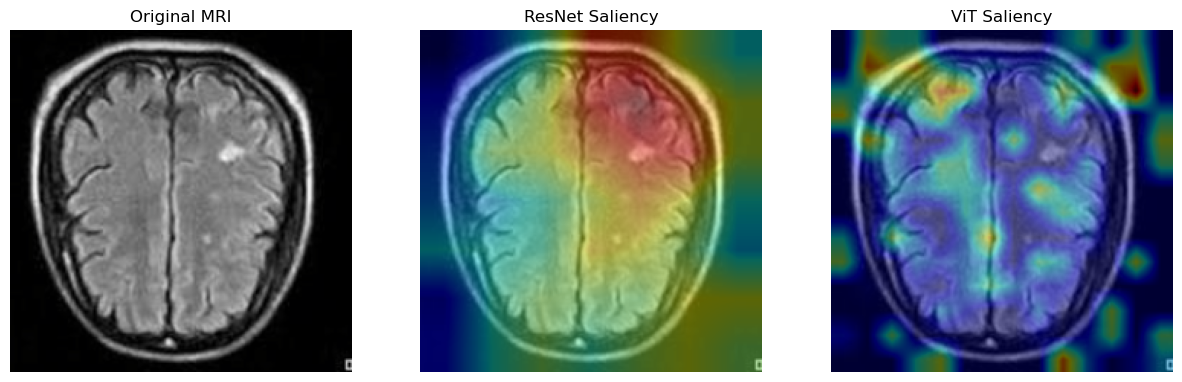

 All results saved to thesis_results/final_export


In [42]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize

# --- 1. DEFINE ARCHITECTURE-SPECIFIC XAI ENGINES ---

class GradCAM_ResNet: # Specific for CNNs
    def __init__(self, model, target_layer):
        self.model, self.target_layer = model, target_layer
        self.gradients, self.features = None, None
        self.hooks = [
            target_layer.register_forward_hook(lambda m, i, o: setattr(self, 'features', o.detach())),
            target_layer.register_full_backward_hook(lambda m, gi, go: setattr(self, 'gradients', go[0].detach()))
        ]
    def generate(self, input_image, target_class):
        self.model.zero_grad()
        output = self.model(input_image)
        loss = output[0, target_class if target_class is not None else output.argmax()]
        loss.backward()
        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)
        cam = torch.sum(weights * self.features, dim=1).squeeze()
        cam = np.maximum(cam.cpu().numpy(), 0)
        cam = cv2.resize(cam, (224, 224))
        return (cam - cam.min()) / (cam.max() - cam.min() + 1e-7)
    def remove(self): 
        for h in self.hooks: h.remove()

class GradCAM_ViT: # Specific for Transformers
    def __init__(self, model, target_layer):
        self.model, self.target_layer = model, target_layer
        self.gradients, self.features = None, None
        self.hooks = [
            target_layer.register_forward_hook(lambda m, i, o: setattr(self, 'features', o.detach())),
            target_layer.register_full_backward_hook(lambda m, gi, go: setattr(self, 'gradients', go[0].detach()))
        ]
    def generate(self, input_image, target_class):
        self.model.zero_grad()
        output = self.model(input_image)
        loss = output[0, target_class if target_class is not None else output.argmax()]
        loss.backward()
        b, t, c = self.features.shape
        grid_size = int(np.sqrt(t - 1)) # 14 for ViT-B/16
        feats = self.features[:, 1:, :].reshape(b, grid_size, grid_size, c).permute(0, 3, 1, 2)
        grads = self.gradients[:, 1:, :].reshape(b, grid_size, grid_size, c).permute(0, 3, 1, 2)
        weights = torch.mean(grads, dim=(2, 3), keepdim=True)
        cam = torch.sum(weights * feats, dim=1).squeeze()
        cam = np.maximum(cam.cpu().numpy(), 0)
        cam = cv2.resize(cam, (224, 224))
        return (cam - cam.min()) / (cam.max() - cam.min() + 1e-7)
    def remove(self): 
        for h in self.hooks: h.remove()

# --- 2. SETUP EXPORT DIRECTORIES ---
output_dir = "thesis_results/final_export"
os.makedirs(output_dir, exist_ok=True)
print("Starting Final Master Export...")

# --- 3. QUANTITATIVE GATHERING (ACCURACY & FAITHFULNESS) ---
def process_model(model, loader, cam_engine):
    model.eval()
    preds, labels, probs, confs, xai_scores, drops = [], [], [], [], [], []
    
    # Classification Metrics
    with torch.no_grad():
        for inputs, lbls in loader:
            inputs = inputs.to(device)
            out = model(inputs)
            prob = torch.softmax(out, dim=1)
            conf, prd = torch.max(prob, 1)
            preds.extend(prd.cpu().numpy())
            labels.extend(lbls.numpy())
            probs.extend(prob.cpu().numpy())
            confs.extend(conf.cpu().numpy())

    # XAI Metrics (on 50 samples for speed)
    for i in range(50):
        img_batch, lbl_batch = next(iter(loader))
        img, lbl = img_batch[0:1].to(device), lbl_batch[0].item()
        
        # Saliency Focus
        heatmap = cam_engine.generate(img, lbl)
        xai_scores.append(np.sum(heatmap > 0.5) / (224*224))
        
        # Faithfulness (Occlusion)
        orig_c = torch.softmax(model(img), dim=1)[0, lbl].item()
        occ_img = img.clone()
        mask = heatmap > 0.8
        for c in range(3): occ_img[0, c, :, :][torch.from_numpy(mask)] = 0
        new_c = torch.softmax(model(occ_img), dim=1)[0, lbl].item()
        drops.append(orig_c - new_c)
        
    cam_engine.remove()
    return np.array(preds), np.array(labels), np.array(probs), np.array(confs), np.array(xai_scores), np.mean(drops)

# Process ResNet
cam_res = GradCAM_ResNet(model, model.layer4[-1])
res_p, res_l, res_pr, res_c, res_xai, res_f = process_model(model, dataloaders['Testing'], cam_res)

# Process ViT
cam_vt = GradCAM_ViT(model_vit, model_vit.encoder.layers.encoder_layer_11.ln_1)
vit_p, vit_l, vit_pr, vit_c, vit_xai, vit_f = process_model(model_vit, dataloaders_vit['Testing'], cam_vt)

# --- 4. SAVE NUMERICAL COMPARISON ---
res_corr = np.corrcoef(res_c[:50], res_xai)[0,1]
vit_corr = np.corrcoef(vit_c[:50], vit_xai)[0,1]

with open(f"{output_dir}/comparison_summary.txt", "w") as f:
    f.write("MSc RESEARCH FINAL COMPARISON\n" + "="*30 + "\n")
    f.write(f"ResNet Accuracy: {np.mean(res_p == res_l)*100:.2f}%\n")
    f.write(f"ViT Accuracy:    {np.mean(vit_p == vit_l)*100:.2f}%\n")
    f.write(f"ResNet Faithfulness (Drop): {res_f:.4f}\n")
    f.write(f"ViT Faithfulness (Drop):    {vit_f:.4f}\n")
    f.write(f"ResNet Correlation (r):     {res_corr:.4f}\n")
    f.write(f"ViT Correlation (r):        {vit_corr:.4f}\n")

# --- 5. VISUAL COMPARISON PLOT ---
inputs, labels = next(iter(dataloaders_vit['Testing']))
img_idx = 0
img_tensor = inputs[img_idx:img_idx+1].to(device)
img_np = np.clip(inputs[img_idx].permute(1,2,0).numpy() * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406], 0, 1)

# Re-init engines for one last generation
engine_r = GradCAM_ResNet(model, model.layer4[-1])
engine_v = GradCAM_ViT(model_vit, model_vit.encoder.layers.encoder_layer_11.ln_1)
h_r = engine_r.generate(img_tensor, labels[img_idx].item())
h_v = engine_v.generate(img_tensor, labels[img_idx].item())

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img_np); ax[0].set_title("Original MRI"); ax[0].axis('off')
ax[1].imshow(img_np); ax[1].imshow(h_r, cmap='jet', alpha=0.4); ax[1].set_title("ResNet Saliency"); ax[1].axis('off')
ax[2].imshow(img_np); ax[2].imshow(h_v, cmap='jet', alpha=0.4); ax[2].set_title("ViT Saliency"); ax[2].axis('off')
plt.savefig(f"{output_dir}/architecture_xai_comparison.png", dpi=300)
plt.show()
engine_r.remove(); engine_v.remove()

print(f" All results saved to {output_dir}")